# Preliminary Thoughts

1. What are you thinking of focusing on?

   We are thinking of on hail and making a system of when hail may be the most severe and most impactful. 
   
2. What makes this hazard or application interesting to explore?

    Hail is interesting to explore because of the damaging affects that come with it. Depending on how large the hail is it can cause a lot of damage to property and may harm human lives.
   
3. Why might it be useful to quantify threat or impact in this area?

   It is useful because as we enter severe weather season people need to be aware of the risks on their property and lives.

- March 10 2026, 12 Z for hail from HRRR
- 48 hours run
- First 24 hours 395 hail reports, final 24 hours 8 hail reports
- 4 Variables we decided on: CAPE (90-0 mb above ground), Vertically Integrated Liquid, Vertical Velocity (Geometric), Composite Reflectivity
- Derived Parameter: Vertically Integrated Liquid Density
- custom colormap: CAPE (90-0 mb above ground)
- Given a HRRR run where the most severe hail would develop based on our variables. That is what our goal is based on what we are trying to calculate with the variables we have selected.
- Cross section plot variables can be vertical velocity (geometric) and composite reflectivity

In [4]:
from herbie import Herbie, FastHerbie
from herbie.toolbox import EasyMap, pc
from herbie import paint
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime, timedelta, time, timezone
import pandas as pd, numpy as np
import xarray as xr
import dask

ds_file = xr.open_dataset("hrrr_2026031012.nc") #ds_file used to open the netcdf file in order for us to use the data to create plots
ds_file

#Plotting CAPE: 255-0 mb above ground

def map(): #map function used to create our base maps when needed
    fig = plt.figure(figsize=(12,9)) #figure size for us to place our base map
    ax = fig.add_subplot(111, projection=ccrs.LambertConformal()) #projection used for our base map
    ax.set_extent([-107,-79,26,44], ccrs.PlateCarree()) #set extent for our base map to zoom into our area of interest
    ax.add_feature(cfeature.COASTLINE) #coastlines added on our map 
    ax.add_feature(cfeature.STATES, linestyle=':')
    ax.add_feature(cfeature.BORDERS)
    return fig, ax

lon = ds_file['longitude'] #getting the longitude from our ds_file so we can plot our data
lat = ds_file['latitude'] #gettting the latitude from our ds_file so we can plot our data
dataproj = ccrs.PlateCarree() #making PlateCarree in our dataproj so we can add it to our pcolormesh
cape_5hr_rolling = ds_file["cape"].rolling(valid_time=5).max() #creating a cape_5hr_rolling so we can see the max amount of cape over a 5 hour period. 
refc_5hr_rolling = ds_file["refc"].rolling(valid_time=5).max() #creating a composite reflectivity so we can see the max amount of composite reflectivity over a 5 hour period.
ds_file = ds_file.rename({"unknown":"cloudtop"})
vil_density =  (ds_file["veril"] /  ds_file["cloudtop"]) *100
vil_density_5hr_rolling = vil_density.rolling(valid_time=5).max()

sh: 1: getfattr: not found


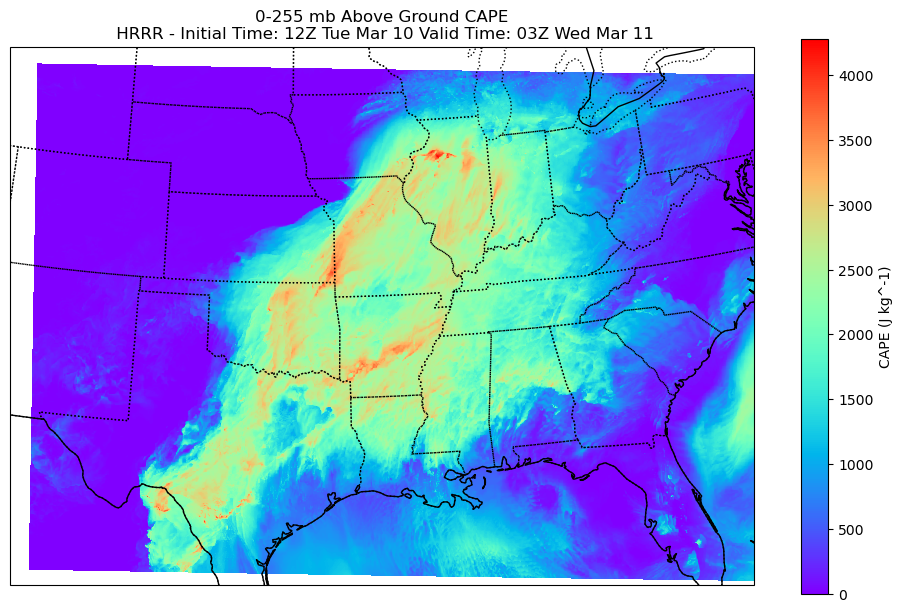

In [5]:
fig, ax = map() #printing out the base map funtion we created above
pcolor = ax.pcolormesh(lon, lat, cape_5hr_rolling.isel(valid_time=15), cmap = 'rainbow', transform = dataproj) #creating the pcolor mesh with the valid_time of 15 with the color map of rainbow and adding longitude and latitude.
plt.colorbar(pcolor, ax=ax, label = 'CAPE (J kg^-1)', shrink = 0.8) #creating a colorbar for our map and shrinking it to a respectable size
ax.set_title(f"0-255 mb Above Ground CAPE\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=15).values):%HZ %a %b %d}") #setting our title with the model type, initial time, valid time, and what it is plotting
plt.show() #plotting our map

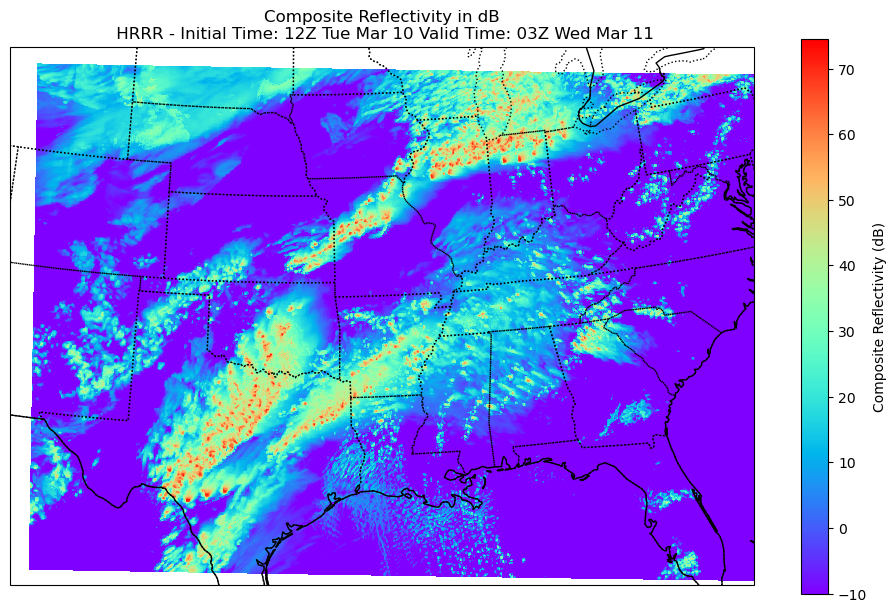

In [6]:
fig,ax=map() #printing our the base map function we created above
pcolor2 = ax.pcolormesh(lon, lat, refc_5hr_rolling.isel(valid_time=15), cmap = 'rainbow', transform = dataproj) #creating the pcolor mesh with the valid_time of 15 with the color map of rainbow and adding longitude and latitude.
plt.colorbar(pcolor2, ax=ax, label = 'Composite Reflectivity (dB)', shrink = 0.8) #creating a colorbar for our map and shrinking it to a respectable size
ax.set_title(f"Composite Reflectivity in dB\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=15).values):%HZ %a %b %d}") #setting our title with the model type, initial time, valid time, and what it is plotting
plt.show() #plotting our map

In [7]:
def vert_velo_index(ds_file,step):
#Vertical Velocity Parameter Index
    vert_velo_5hr_rolling = ds_file["wz"].rolling(valid_time=5).max()
    vert_velo_5hr_rolling_time = vert_velo_5hr_rolling.isel(valid_time=step).values
    vert_velo_contribution = np.zeros_like(vert_velo_5hr_rolling_time)

    mask = (vert_velo_5hr_rolling_time >= 0) & (vert_velo_5hr_rolling_time < 0.55)
    vert_velo_contribution[mask] = (vert_velo_5hr_rolling_time[mask] - 0) / 1.45

    mask = (vert_velo_5hr_rolling_time >= 0.55) & (vert_velo_5hr_rolling_time < 1.2)
    vert_velo_contribution[mask] = (vert_velo_5hr_rolling_time[mask] - 0.20) / 1

    mask = (vert_velo_5hr_rolling_time >= 1.2)
    vert_velo_contribution[mask] = 1
    return vert_velo_contribution

In [8]:
#fig, ax = map()
#cmap1 = plt.get_cmap('Reds')
#cmap1.set_under('white')
#pcolor3 = ax.pcolormesh(lon,lat,vert_velo_index(ds_file,9), cmap=cmap1, vmin=0.1, transform = dataproj)
#plt.colorbar(pcolor3, ax=ax, label = 'Vertical Velocity (m s**-1)', shrink = 0.8)
#plt.show()

In [9]:
def vil_density_index(ds_file,step):
# Start with all contributions set to 0
    vil_density_5hr_rolling_time =vil_density_5hr_rolling.isel(valid_time=step).values
    vil_density_contribution = np.zeros_like(vil_density_5hr_rolling_time)


    mask = (vil_density_5hr_rolling_time >= 0.25) & (vil_density_5hr_rolling_time < 1.75 )
    vil_density_contribution[mask] = (vil_density_5hr_rolling_time[mask] - 0.25) / 1.50




    mask = (vil_density_5hr_rolling_time >= 1.75) 
    vil_density_contribution[mask] = 1.0
    return vil_density_contribution

#fig, ax = map() #printing out the base map funtion we created above
#pcolor = ax.pcolormesh(lon, lat, vil_density_index(ds_file,24), cmap = 'gist_heat_r', transform =ccrs.PlateCarree()) #creating the pcolor mesh with the valid_time of 15 with the color map of gist heat in reverse and adding longitude and latitude.
#plt.colorbar(pcolor, ax=ax, shrink = 0.8)

In [10]:
def refc_index(ds_file, step):
    refc_5hr_rolling = ds_file['refc'].rolling(valid_time=5).max()
    refc_5hr_rolling_time = refc_5hr_rolling.isel(valid_time=step).values
    refc_contribution = np.zeros_like(refc_5hr_rolling_time)

    # Setting the index = 0 if reflectivity is less than 45 
    mask = refc_5hr_rolling_time < 45
    refc_contribution[mask] = 0

    # Creating a linearly increasing index from 0 to 1, for reflectivity in betwene 45 and 60 (inclusive)
    mask = (refc_5hr_rolling_time >= 45) & (refc_5hr_rolling_time <= 60)
    refc_contribution[mask] = ((refc_5hr_rolling_time[mask] - 45) / 15)

    # Setting the index = 1 if reflectivty is greater than 60
    mask = refc_5hr_rolling_time > 60
    refc_contribution[mask] = 1
    return refc_contribution

# Plotting the index on the geographical map
#fig,ax = map()
#refc_inde = ax.pcolormesh(ds_file.longitude, ds_file.latitude, refc_inde(ds_file,15), cmap = 'Reds', transform=ccrs.PlateCarree())
#plt.colorbar(refc_index, ax=ax, label = 'Reflectivity Index', shrink = 0.8) #creating a colorbar for our map and shrinking it to a respectable size

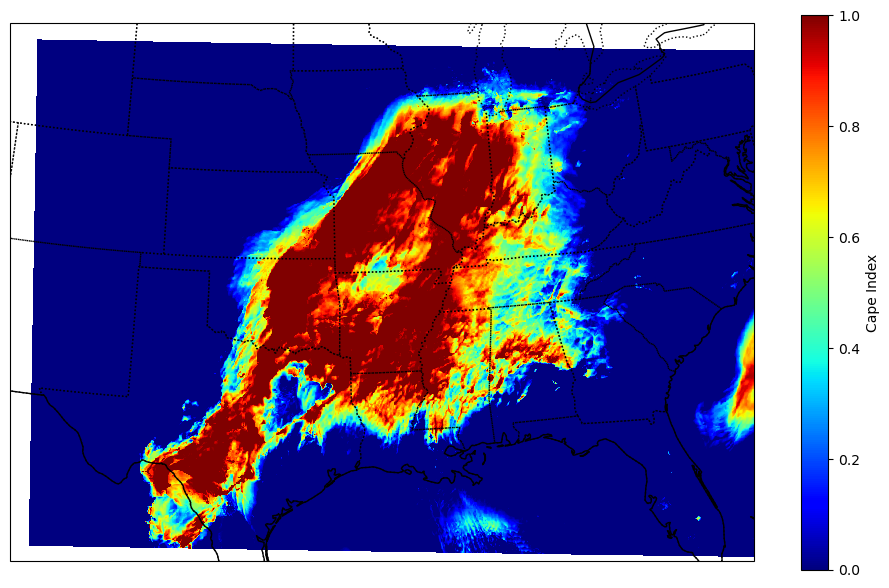

In [11]:
def cape_index(ds_file,step):

    cape_5hr_rolling = ds_file['cape'].rolling(valid_time=5).max()
    cape_5hr_rolling_time = cape_5hr_rolling.isel(valid_time=step).values
    cape_contribution = np.zeros_like(cape_5hr_rolling_time)

    # Setting the index = 0 if CAPE is less than 1250
    mask = (cape_5hr_rolling_time < 1250)
    cape_contribution[mask] = 0

    # Creating a linearly increasing index from 0 to 1, for CAPE in between 1250 and 2500 (inclusive)
    mask = (cape_5hr_rolling_time >= 1250) & (cape_5hr_rolling_time <= 2500)
    cape_contribution[mask] = (cape_5hr_rolling_time[mask] - 1250) / 1250

    # Setting the index = 1 if CAPE is greater than 2500
    mask = cape_5hr_rolling_time > 2500
    cape_contribution[mask] = 1
    return cape_contribution

# Plotting the index on the geographical map
fig,ax = map()
cape_ind = ax.pcolormesh(ds_file.longitude, ds_file.latitude, cape_index(ds_file,15), cmap = 'jet', transform=ccrs.PlateCarree())
plt.colorbar(cape_ind, ax=ax, label = 'Cape Index', shrink = 0.8) #creating a colorbar for our map and shrinking it to a respectable size

In [12]:
def hail_index(ds_file,step):
    cape_5hr_rolling = ds_file['cape'].rolling(valid_time=5).max()
    cape_5hr_rolling_time = cape_5hr_rolling.isel(valid_time=step).values
    cape_contribution = np.zeros_like(cape_5hr_rolling_time)

    # Setting the index = 0 if CAPE is less than 1250
    mask = (cape_5hr_rolling_time < 1250)
    cape_contribution[mask] = 0

    # Creating a linearly increasing index from 0 to 1, for CAPE in between 1250 and 2500 (inclusive)
    mask = (cape_5hr_rolling_time >= 1250) & (cape_5hr_rolling_time <= 2500)
    cape_contribution[mask] = (cape_5hr_rolling_time[mask] - 1250) / 1250

    # Setting the index = 1 if CAPE is greater than 2500
    mask = cape_5hr_rolling_time > 2500
    cape_contribution[mask] = 1

    refc_5hr_rolling = ds_file['refc'].rolling(valid_time=5).max()
    refc_5hr_rolling_time = refc_5hr_rolling.isel(valid_time=step).values
    refc_contribution = np.zeros_like(refc_5hr_rolling_time)

    # Setting the index = 0 if reflectivity is less than 45 
    mask = refc_5hr_rolling_time < 45
    refc_contribution[mask] = 0

    # Creating a linearly increasing index from 0 to 1, for reflectivity in betwene 45 and 60 (inclusive)
    mask = (refc_5hr_rolling_time >= 45) & (refc_5hr_rolling_time <= 60)
    refc_contribution[mask] = ((refc_5hr_rolling_time[mask] - 45) / 15)

    # Setting the index = 1 if reflectivty is greater than 60
    mask = refc_5hr_rolling_time > 60
    refc_contribution[mask] = 1

    vil_density_5hr_rolling_time =vil_density_5hr_rolling.isel(valid_time=step).values
    vil_density_contribution = np.zeros_like(vil_density_5hr_rolling_time)

    mask = (vil_density_5hr_rolling_time >= 0.25) & (vil_density_5hr_rolling_time < 1.75 )
    vil_density_contribution[mask] = (vil_density_5hr_rolling_time[mask] - 0.25) / 1.50

    mask = (vil_density_5hr_rolling_time >= 1.75) 
    vil_density_contribution[mask] = 1.0

    vert_velo_5hr_rolling = ds_file["wz"].rolling(valid_time=5).max()
    vert_velo_5hr_rolling_time = vert_velo_5hr_rolling.isel(valid_time=step).values
    vert_velo_contribution = np.zeros_like(vert_velo_5hr_rolling_time)

    mask = (vert_velo_5hr_rolling_time >= 0) & (vert_velo_5hr_rolling_time < 0.55)
    vert_velo_contribution[mask] = (vert_velo_5hr_rolling_time[mask] - 0) / 1.45

    mask = (vert_velo_5hr_rolling_time >= 0.55) & (vert_velo_5hr_rolling_time < 1.2)
    vert_velo_contribution[mask] = (vert_velo_5hr_rolling_time[mask] - 0.20) / 1

    mask = (vert_velo_5hr_rolling_time >= 1.2)
    vert_velo_contribution[mask] = 1

    hail_index_calc = (cape_contribution * 0.20 + refc_contribution * 0.225 + vil_density_contribution * 0.35 + vert_velo_contribution * 0.225) * 100
    return hail_index_calc

hail_index(ds_file,15)
#hail_index(ds_file,10) what you would type when you are trying to plot for the 6 different time steps

array([[ 0.        ,  7.895343  , 12.434158  , ...,  2.5367224 ,
         1.7367225 ,  1.2567225 ],
       [ 0.        ,  0.        ,  0.42514306, ...,  1.8967224 ,
         1.2567225 ,  1.7367225 ],
       [ 0.        ,  5.2742805 ,  0.        , ...,  1.4167224 ,
         1.2567225 ,  2.2167225 ],
       ...,
       [ 3.1405668 ,  1.2009119 ,  1.2009119 , ...,  0.        ,
         1.2009119 ,  0.        ],
       [ 0.2310843 ,  1.2009119 ,  2.1707394 , ...,  0.84922063,
         0.        ,  0.2310843 ],
       [ 0.04079917,  1.9804543 ,  0.04079917, ...,  0.84922063,
         0.        ,  0.42514306]], shape=(650, 950), dtype=float32)

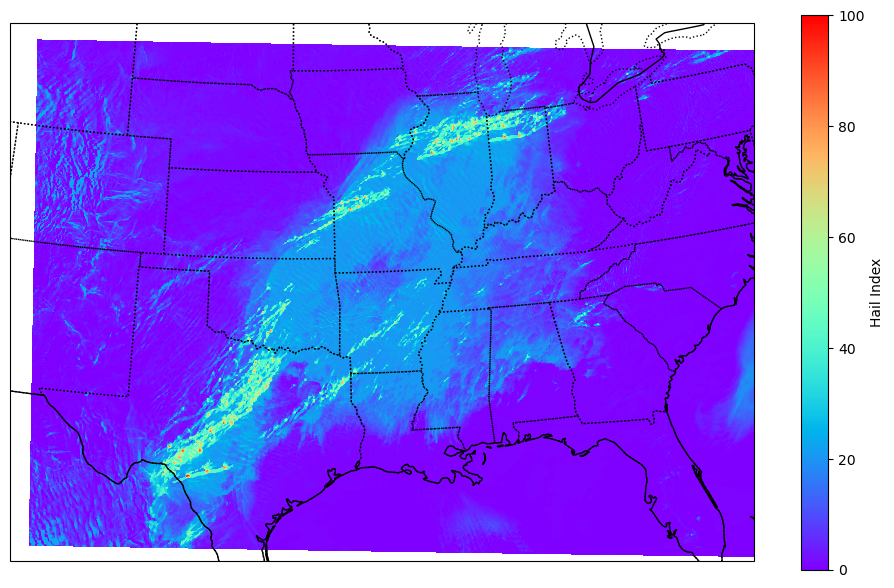

In [13]:
fig,ax = map()
pcolor4 = ax.pcolormesh(lon,lat, hail_index(ds_file,15), cmap= 'rainbow', vmax = 100, transform = dataproj)
plt.colorbar(pcolor4, ax=ax, label = 'Hail Index', shrink = 0.8)
plt.show()

In [26]:
#Code for visualizing the output worked on by Myles
#Used GeminiAI to figure out how to create the for loop for the function
def map2(rows,cols): #map function used to create our base maps when needed
    fig,axes = plt.subplots(rows,cols,figsize=(24,12),subplot_kw = {"projection":ccrs.LambertConformal()}) #figure size for us to place our base map
    flat_axes = axes.flatten() #used axes.flatten to make the loop simpler for the for loop
    for i, ax in enumerate(flat_axes): #for loop to enumerate the flat_axes or the list of subplots
        if i == 5: #this is to make sure there is only 5 maps and that it hides the 6th map being created.
            ax.set_visible(False)
            continue  
        ax.set_extent([-107,-79,26,44], ccrs.PlateCarree()) #set extent for our base map to zoom into our area of interest
        ax.add_feature(cfeature.COASTLINE) #coastlines added on our map 
        ax.add_feature(cfeature.STATES, linestyle=':')
        ax.add_feature(cfeature.BORDERS)
    plt.tight_layout() #used tight_layout to make sure everything aligns perfectly and that nothing overlaps
    return fig, axes

from matplotlib.colors import ListedColormap
custom_cmap = [ #from notebook.community
    "white", # ND
    "white", # -30
    "mistyrose", # -25
    "darksalmon", # -20
    "orangered", # -15
    "red", # -10
    "firebrick", # -5
    "maroon", # 0
    ]

realcmap = ListedColormap(custom_cmap, name='nws_reflectivity_colors')

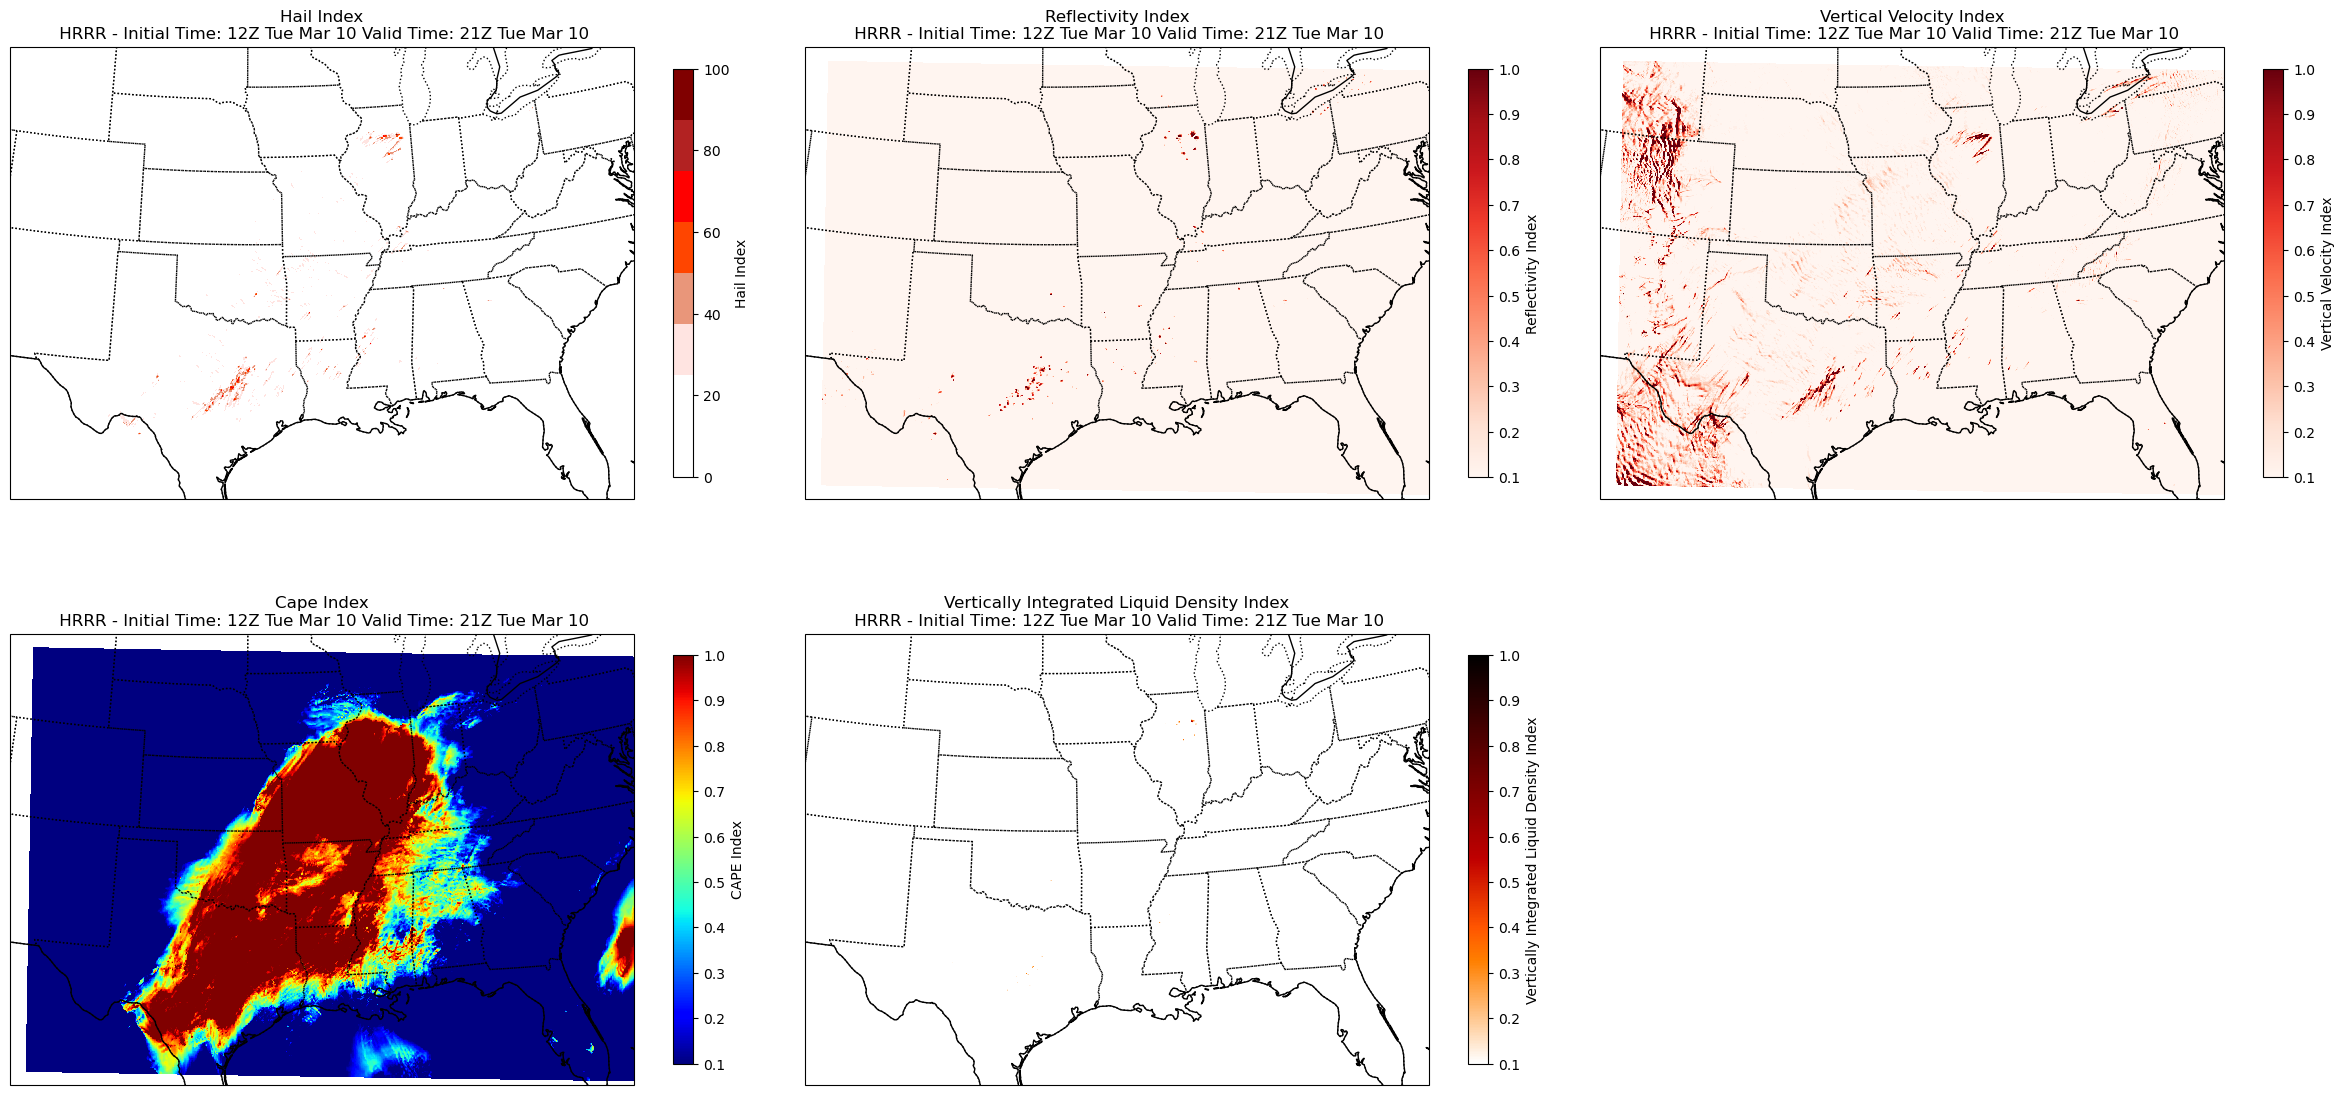

In [27]:
fig, axes = map2(2,3) #calling map2 function
pcolor4 = axes[0,0].pcolormesh(lon, lat, hail_index(ds_file,9), cmap = realcmap, vmax = 100, transform = dataproj) #creating a pcolormesh map for hail index at step 9
plt.colorbar(pcolor4, ax=axes[0,0], label = 'Hail Index', shrink = 0.7) #creating colorbar for the map
axes[0,0].set_title(f"Hail Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=9).values):%HZ %a %b %d}") #title for map at step 9 with model name, valid time and initial time

pcolor5 = axes[1,0].pcolormesh(lon, lat, cape_index(ds_file,9), cmap = 'jet', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for cape index at step 9
plt.colorbar(pcolor5, ax=axes[1,0], label = 'CAPE Index', shrink = 0.7) #creating colorbar for the map
axes[1,0].set_title(f"Cape Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=9).values):%HZ %a %b %d}") #title for map at step 9 with model name, valid time and initial time

pcolor6 = axes[0,1].pcolormesh(lon, lat, refc_index(ds_file,9), cmap = 'Reds', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for reflectivity index at step 9
plt.colorbar(pcolor6, ax=axes[0,1], label = 'Reflectivity Index', shrink = 0.7) #creating colorbar for the map
axes[0,1].set_title(f"Reflectivity Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=9).values):%HZ %a %b %d}") #title for map at step 9 with model name, valid time and initial time

pcolor7 = axes[1,1].pcolormesh(lon, lat, vil_density_index(ds_file,9), cmap = 'gist_heat_r', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for vil density index at step 9
plt.colorbar(pcolor7, ax=axes[1,1], label = 'Vertically Integrated Liquid Density Index', shrink = 0.7) #creating colorbar for the map
axes[1,1].set_title(f"Vertically Integrated Liquid Density Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=9).values):%HZ %a %b %d}") #title for map at step 9 with model name, valid time and initial time

pcolor8 =  axes[0,2].pcolormesh(lon, lat, vert_velo_index(ds_file,9), cmap = 'Reds', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for vert velo index at step 9
plt.colorbar(pcolor8, ax=axes[0,2], label = 'Vertical Velocity Index', shrink = 0.7) #creating colorbar for the map
axes[0,2].set_title(f"Vertical Velocity Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=9).values):%HZ %a %b %d}") #title for map at step 9 with model name, valid time, and initial time
plt.show()

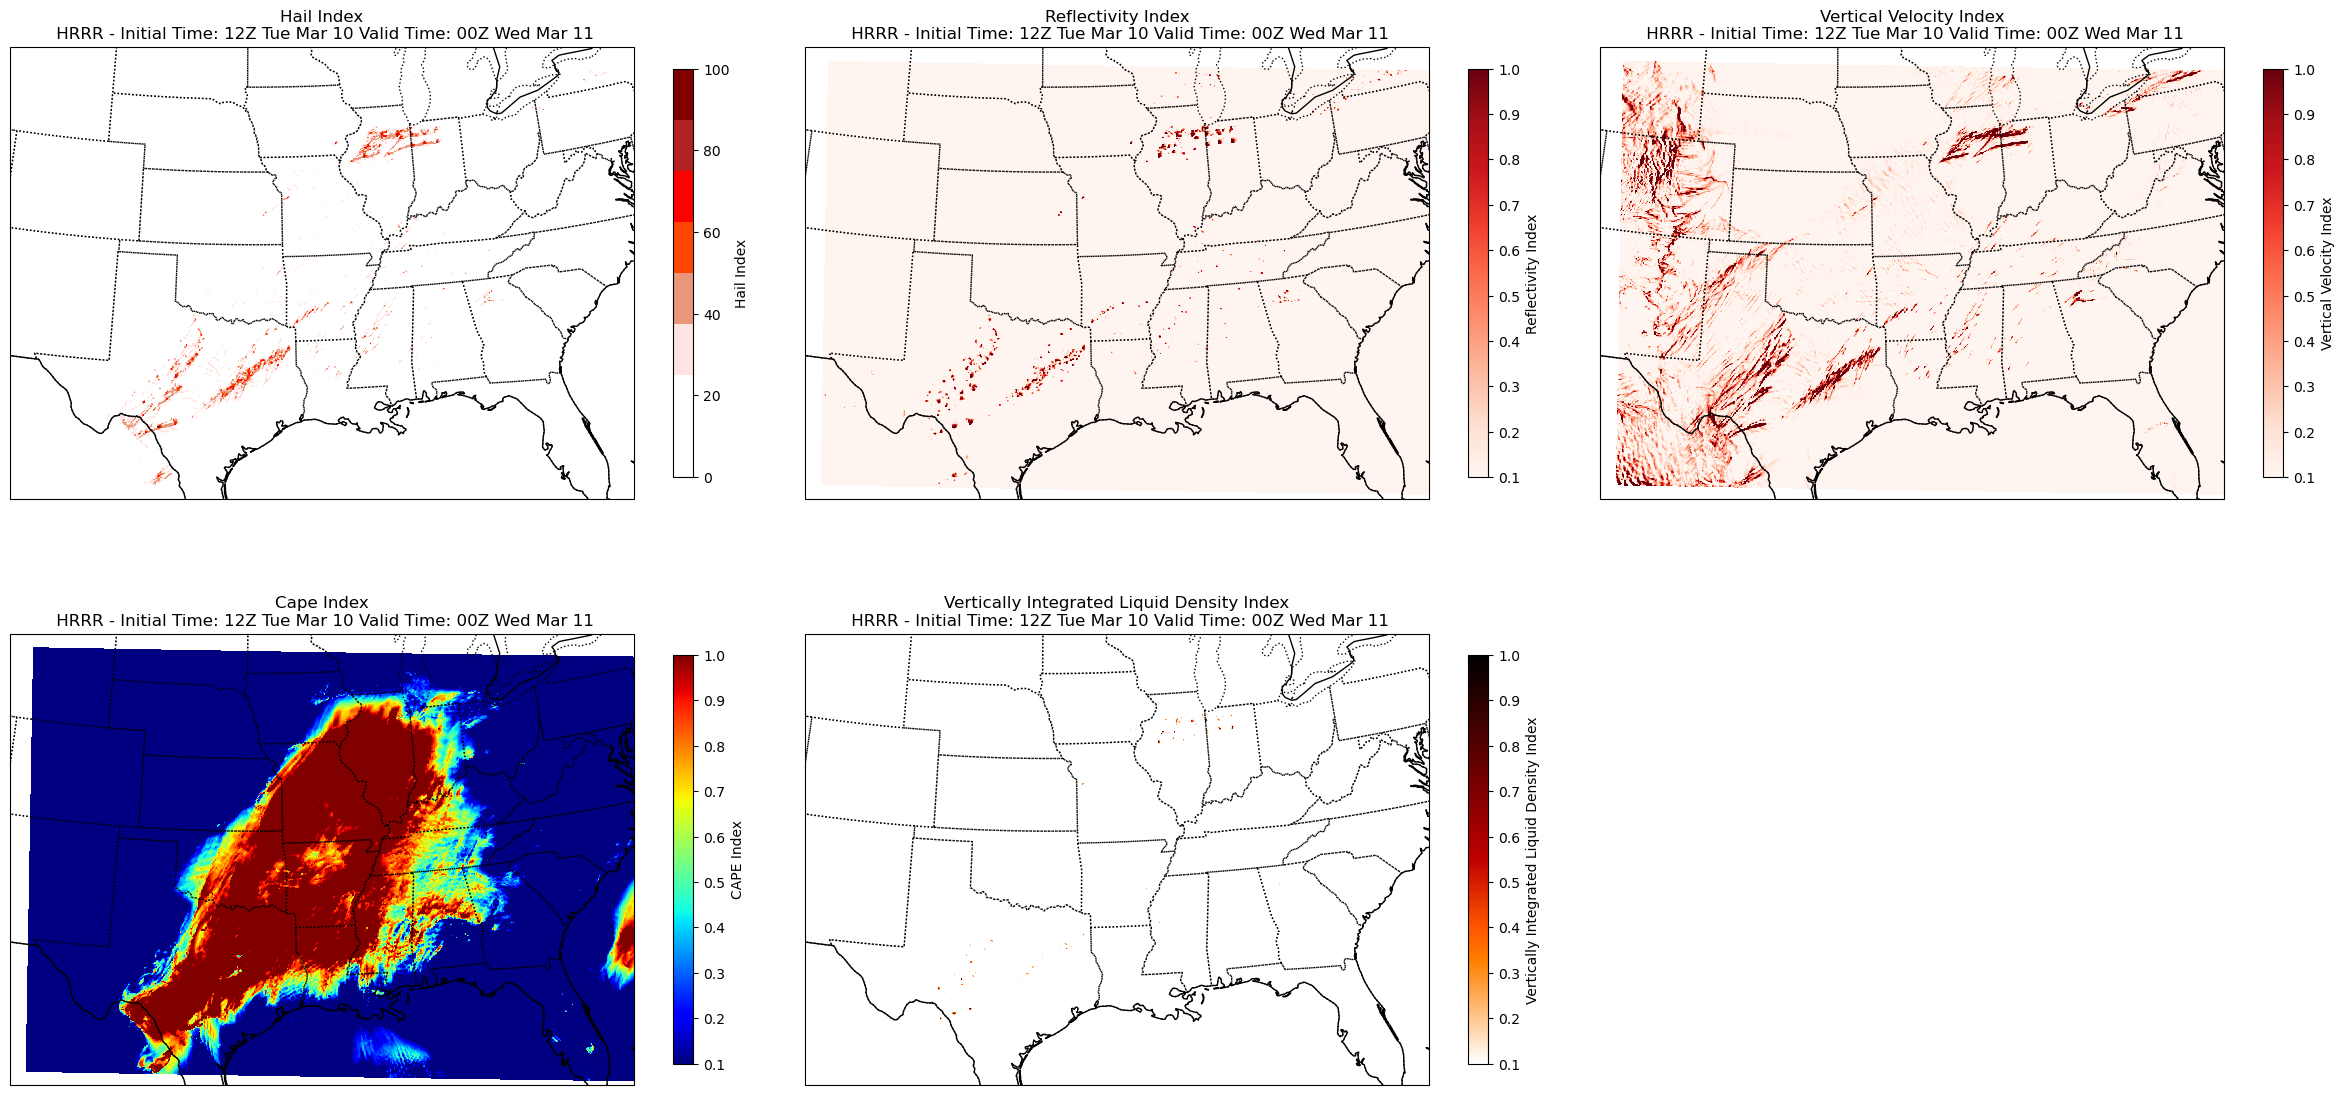

In [28]:
fig, axes = map2(2,3) #calling map2 function
pcolor9 = axes[0,0].pcolormesh(lon, lat, hail_index(ds_file,12), cmap = realcmap, vmax = 100, transform = dataproj) #creating a pcolormesh map for hail index at step 12
plt.colorbar(pcolor9, ax=axes[0,0], label = 'Hail Index', shrink = 0.7) #creating colorbar for the map
axes[0,0].set_title(f"Hail Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=12).values):%HZ %a %b %d}") #title for map at step 12 with model name, valid time and initial time

pcolor10 = axes[1,0].pcolormesh(lon, lat, cape_index(ds_file,12), cmap = 'jet', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for cape index at step 12
plt.colorbar(pcolor10, ax=axes[1,0], label = 'CAPE Index', shrink = 0.7) #creating colorbar for the map
axes[1,0].set_title(f"Cape Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=12).values):%HZ %a %b %d}") #title for map at step 12 with model name, valid time and initial time

pcolor11 = axes[0,1].pcolormesh(lon, lat, refc_index(ds_file,12), cmap = 'Reds', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for reflectivity index at step 12
plt.colorbar(pcolor11, ax=axes[0,1], label = 'Reflectivity Index', shrink = 0.7) #creating colorbar for the map
axes[0,1].set_title(f"Reflectivity Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=12).values):%HZ %a %b %d}") #title for map at step 12 with model name, valid time and initial time

pcolor12 = axes[1,1].pcolormesh(lon, lat, vil_density_index(ds_file,12), cmap = 'gist_heat_r', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for vil density index at step 12
plt.colorbar(pcolor12, ax=axes[1,1], label = 'Vertically Integrated Liquid Density Index', shrink = 0.7) #creating colorbar for the map
axes[1,1].set_title(f"Vertically Integrated Liquid Density Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=12).values):%HZ %a %b %d}") #title for map at step 12 with model name, valid time and initial time

pcolor13 =  axes[0,2].pcolormesh(lon, lat, vert_velo_index(ds_file,12), cmap = 'Reds', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for vert velo density index at step 12
plt.colorbar(pcolor13, ax=axes[0,2], label = 'Vertical Velocity Index', shrink = 0.7) #creating colorbar for the map
axes[0,2].set_title(f"Vertical Velocity Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=12).values):%HZ %a %b %d}") #title for map at step 12 with model name, valid time and initial time
plt.show()

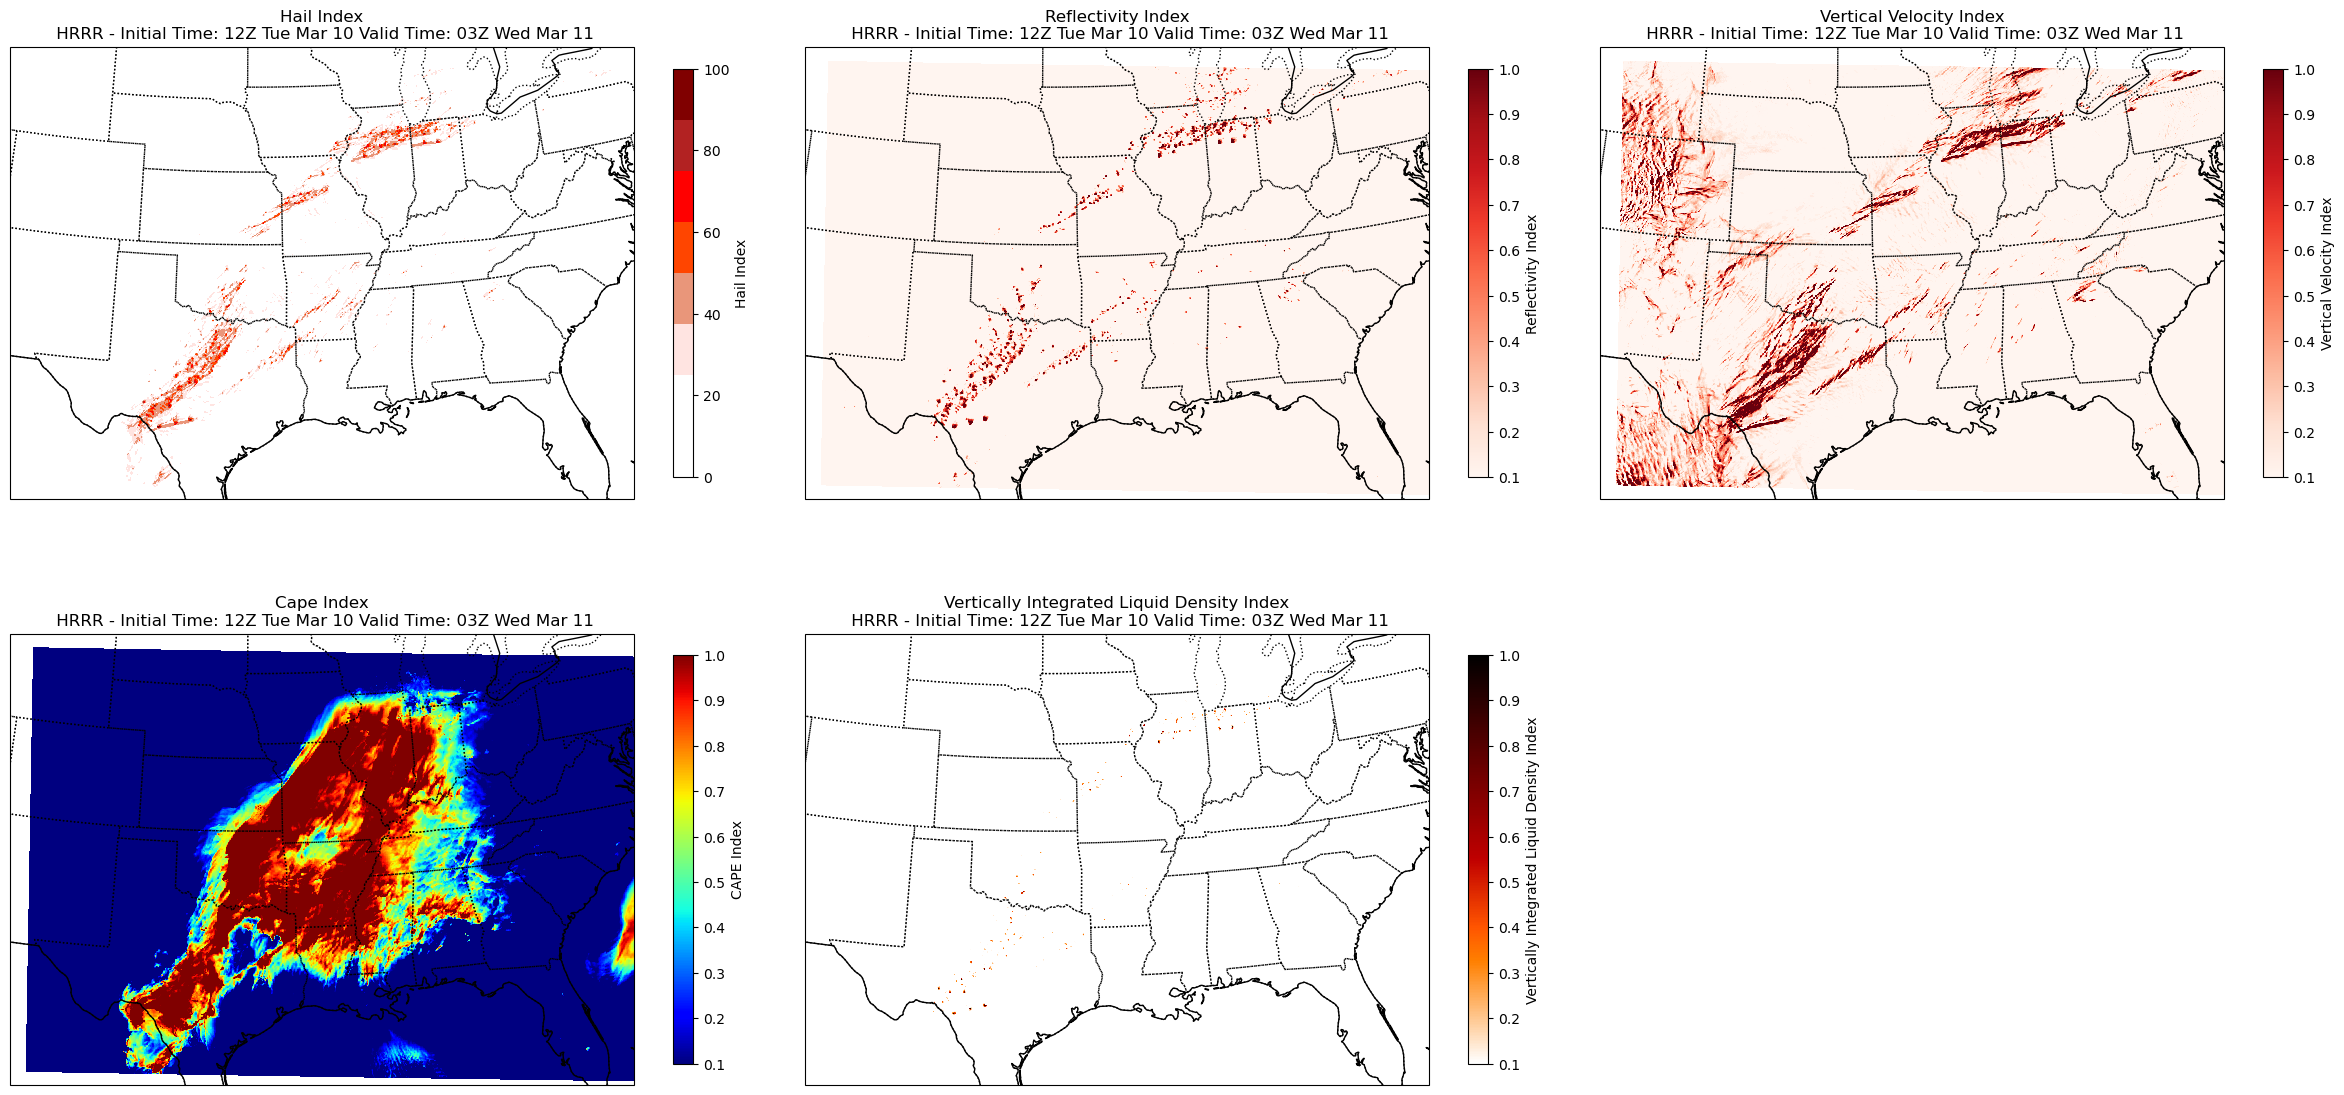

In [29]:
fig, axes = map2(2,3) #calling map2 function
pcolor14 = axes[0,0].pcolormesh(lon, lat, hail_index(ds_file,15), cmap = realcmap, vmax = 100, transform = dataproj) #creating a pcolormesh map for hail index at step 15
plt.colorbar(pcolor14, ax=axes[0,0], label = 'Hail Index', shrink = 0.7) #creating colorbar for the map
axes[0,0].set_title(f"Hail Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=15).values):%HZ %a %b %d}") #title for map at step 15 with model name, valid time and initial time

pcolor15 = axes[1,0].pcolormesh(lon, lat, cape_index(ds_file,15), cmap = 'jet', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for the cape index at step 15
plt.colorbar(pcolor15, ax=axes[1,0], label = 'CAPE Index', shrink = 0.7) #creating colorbar for the map
axes[1,0].set_title(f"Cape Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=15).values):%HZ %a %b %d}") #title for map at step 15 with model name, valid time and initial time

pcolor16 = axes[0,1].pcolormesh(lon, lat, refc_index(ds_file,15), cmap = 'Reds', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for the reflectivity index at step 15
plt.colorbar(pcolor16, ax=axes[0,1], label = 'Reflectivity Index', shrink = 0.7) #creating colorbar for the map
axes[0,1].set_title(f"Reflectivity Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=15).values):%HZ %a %b %d}") #title for map at step 15 with model name, valid time and initial time

pcolor17 = axes[1,1].pcolormesh(lon, lat, vil_density_index(ds_file,15), cmap = 'gist_heat_r', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for vil density index at step 15
plt.colorbar(pcolor17, ax=axes[1,1], label = 'Vertically Integrated Liquid Density Index', shrink = 0.7) #creating colorbar for the map
axes[1,1].set_title(f"Vertically Integrated Liquid Density Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=15).values):%HZ %a %b %d}") #title for map at step 15 with model name, valid time and initial time

pcolor18 =  axes[0,2].pcolormesh(lon, lat, vert_velo_index(ds_file,15), cmap = 'Reds', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for vert velo index at step 15
plt.colorbar(pcolor18, ax=axes[0,2], label = 'Vertical Velocity Index', shrink = 0.7) #creating colorbar for the map
axes[0,2].set_title(f"Vertical Velocity Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=15).values):%HZ %a %b %d}") #title for map at step 15 with model name, valid time and initial time
plt.show()

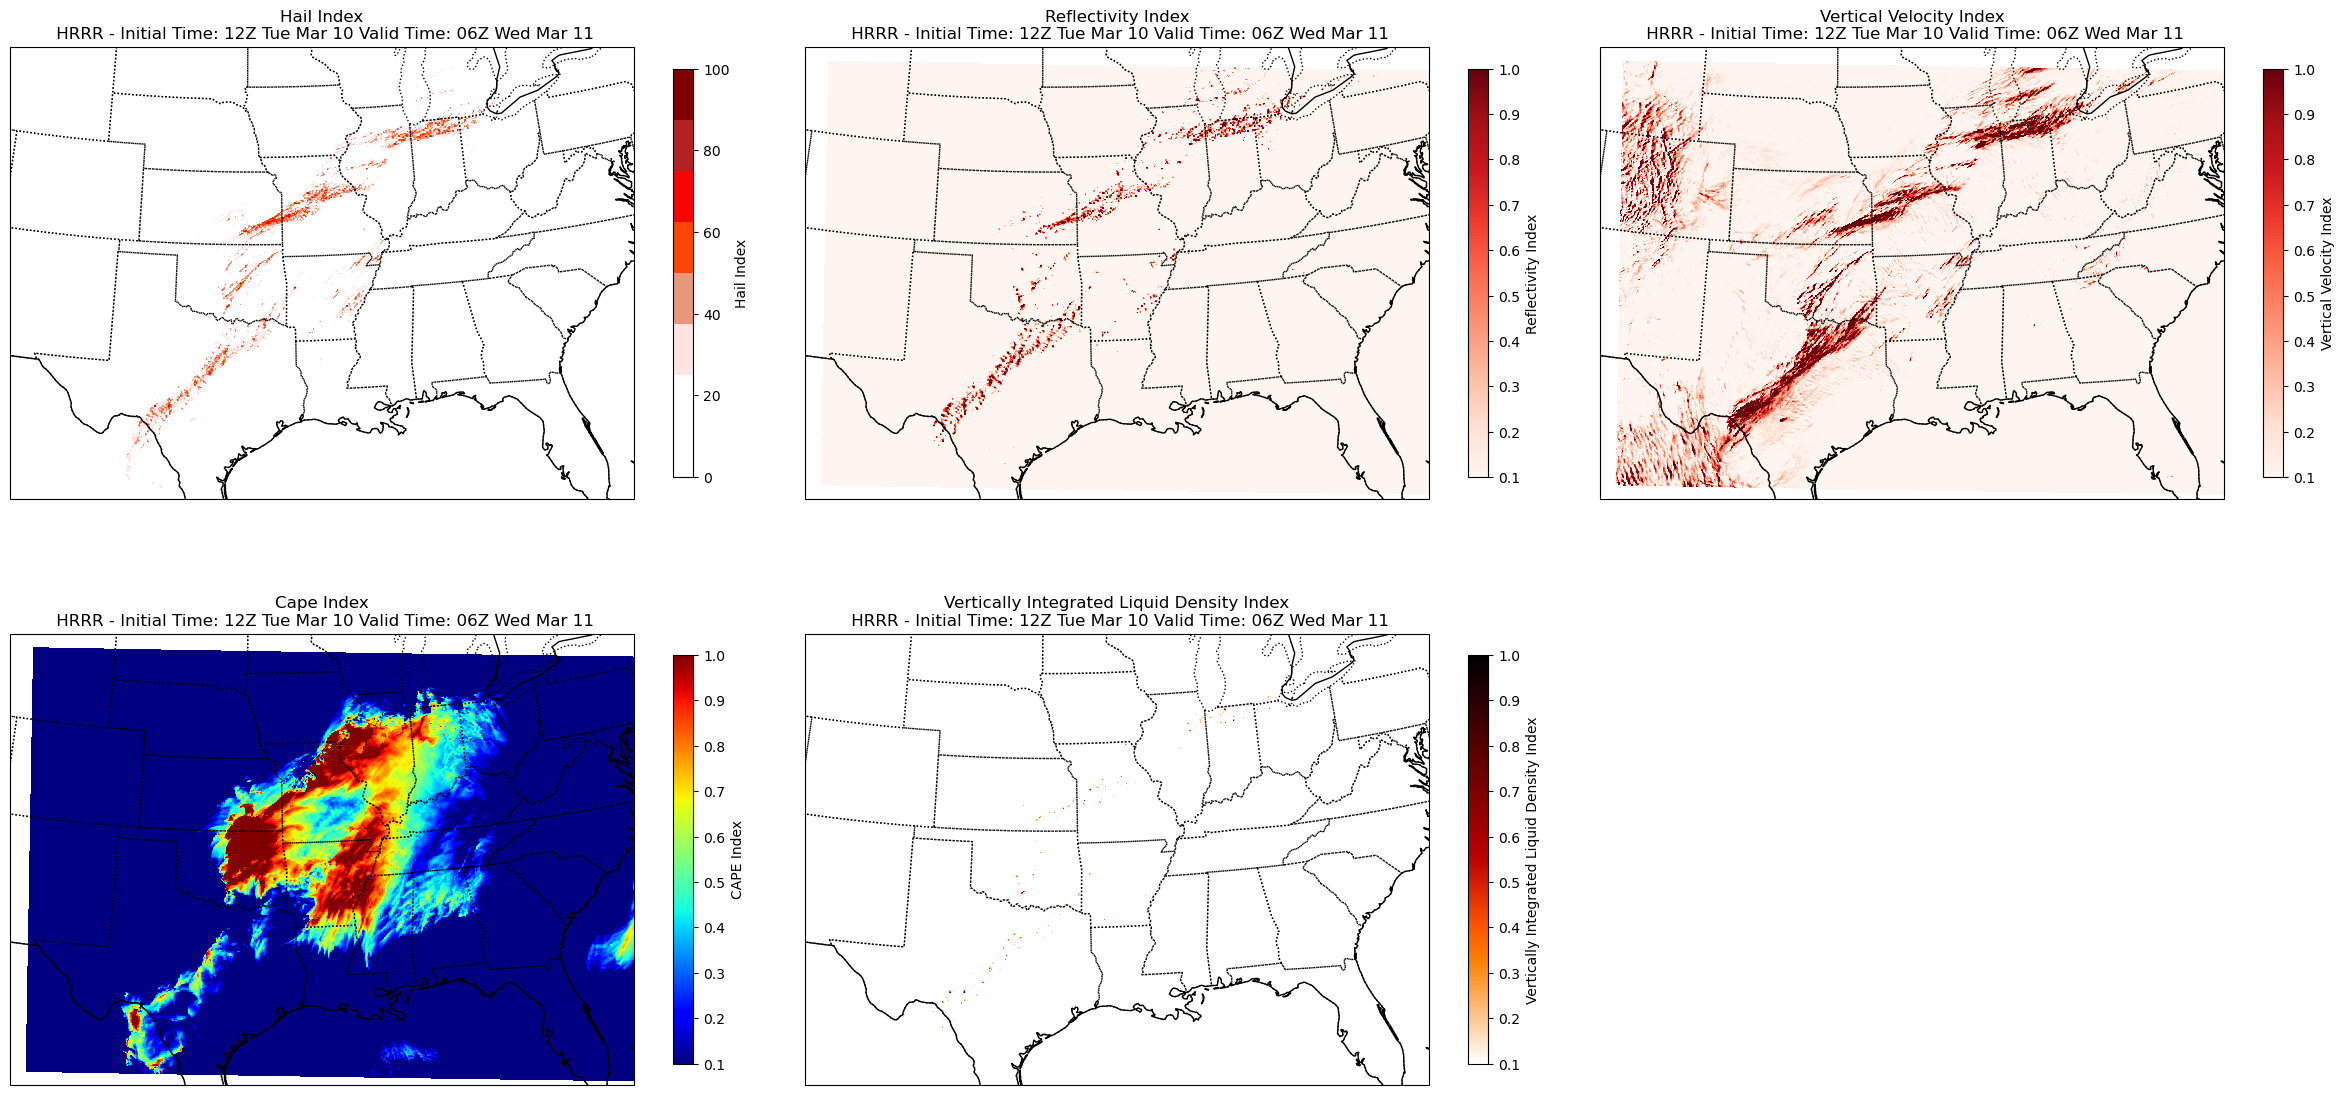

In [30]:
fig, axes = map2(2,3) #calling map2 function
pcolor19 = axes[0,0].pcolormesh(lon, lat, hail_index(ds_file,18), cmap = realcmap, vmax = 100, transform = dataproj) #creating a pcolormesh map for hail index at step 18
plt.colorbar(pcolor19, ax=axes[0,0], label = 'Hail Index', shrink = 0.7) #creating colorbar for the map
axes[0,0].set_title(f"Hail Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=18).values):%HZ %a %b %d}") #title for map at step 18 with model name, valid time and initial time

pcolor20 = axes[1,0].pcolormesh(lon, lat, cape_index(ds_file,18), cmap = 'jet', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for cape index at step 18
plt.colorbar(pcolor20, ax=axes[1,0], label = 'CAPE Index', shrink = 0.7) #creating colorbar for the map
axes[1,0].set_title(f"Cape Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=18).values):%HZ %a %b %d}") #title for map at step 18 with model name, valid time and initial time

pcolor21 = axes[0,1].pcolormesh(lon, lat, refc_index(ds_file,18), cmap = 'Reds', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for reflectivity index at step 18
plt.colorbar(pcolor21, ax=axes[0,1], label = 'Reflectivity Index', shrink = 0.7) #creating colorbar for the map
axes[0,1].set_title(f"Reflectivity Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=18).values):%HZ %a %b %d}") #title for map at step 18 with model name, valid time and initial time

pcolor22 = axes[1,1].pcolormesh(lon, lat, vil_density_index(ds_file,18), cmap = 'gist_heat_r', vmin = 0.1, vmax = 1, transform = dataproj) #creating a pcolormesh map for vil density index at step 18
plt.colorbar(pcolor22, ax=axes[1,1], label = 'Vertically Integrated Liquid Density Index', shrink = 0.7) #creating colorbar for the map
axes[1,1].set_title(f"Vertically Integrated Liquid Density Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=18).values):%HZ %a %b %d}") #title for map at step 18 with model name, valid time and initial time

pcolor23 =  axes[0,2].pcolormesh(lon, lat, vert_velo_index(ds_file,18), cmap = 'Reds', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for vert velo index at step 18
plt.colorbar(pcolor23, ax=axes[0,2], label = 'Vertical Velocity Index', shrink = 0.7) #creating colorbar for the map
axes[0,2].set_title(f"Vertical Velocity Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=18).values):%HZ %a %b %d}") #title for map at step 18 with model name, valid time and initial time
plt.show()

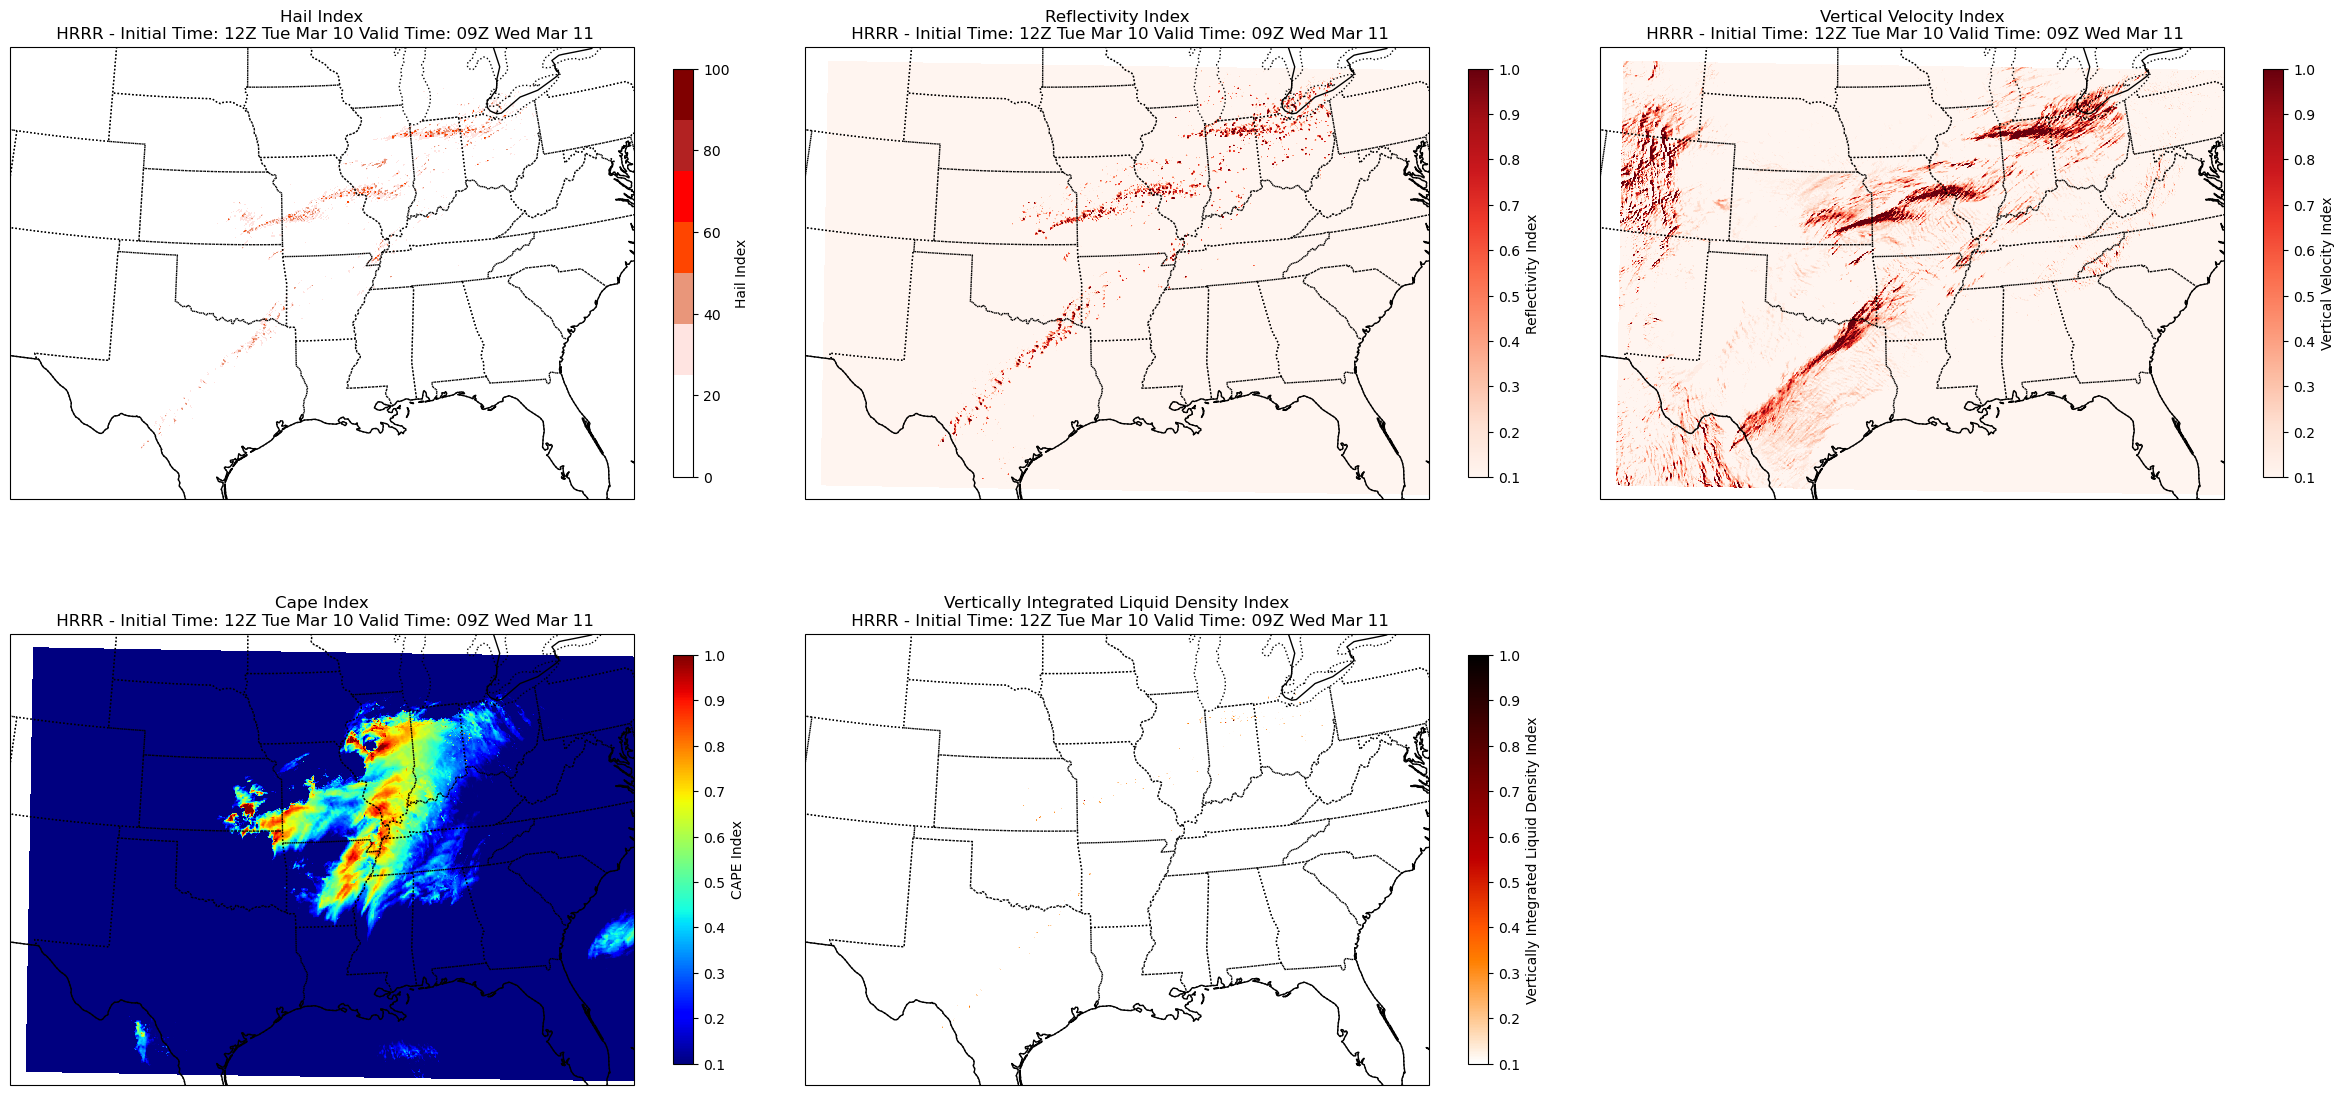

In [31]:
fig, axes = map2(2,3) #calling map2 function
pcolor24 = axes[0,0].pcolormesh(lon, lat, hail_index(ds_file,21), cmap = realcmap, vmax = 100, transform = dataproj) #creating a pcolormesh map for hail index at step 21
plt.colorbar(pcolor24, ax=axes[0,0], label = 'Hail Index', shrink = 0.7) #creating colorbar for the map
axes[0,0].set_title(f"Hail Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=21).values):%HZ %a %b %d}") #title for map at step 21 with model name, valid time and initial time

pcolor25 = axes[1,0].pcolormesh(lon, lat, cape_index(ds_file,21), cmap = 'jet', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for cape index at step 21
plt.colorbar(pcolor25, ax=axes[1,0], label = 'CAPE Index', shrink = 0.7) #creating colorbar for the map
axes[1,0].set_title(f"Cape Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=21).values):%HZ %a %b %d}") #title for map at step 21 with model name, valid time and initial time

pcolor26 = axes[0,1].pcolormesh(lon, lat, refc_index(ds_file,21), cmap = 'Reds', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for reflectivity index at step 21
plt.colorbar(pcolor26, ax=axes[0,1], label = 'Reflectivity Index', shrink = 0.7) #creating colorbar for the map
axes[0,1].set_title(f"Reflectivity Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=21).values):%HZ %a %b %d}") #title for map at step 21 with model name, valid time and initial time

pcolor27 = axes[1,1].pcolormesh(lon, lat, vil_density_index(ds_file,21), cmap = 'gist_heat_r', vmin = 0.1, vmax = 1, transform = dataproj) #creating a pcolormesh map for vil density index at step 21
plt.colorbar(pcolor27, ax=axes[1,1], label = 'Vertically Integrated Liquid Density Index', shrink = 0.7) #creating colorbar for the map
axes[1,1].set_title(f"Vertically Integrated Liquid Density Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=21).values):%HZ %a %b %d}") #title for map at step 21 with model name, valid time and initial time

pcolor28 =  axes[0,2].pcolormesh(lon, lat, vert_velo_index(ds_file,21), cmap = 'Reds', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for vert velo index at step 21
plt.colorbar(pcolor28, ax=axes[0,2], label = 'Vertical Velocity Index', shrink = 0.7) #creating colorbar for the map
axes[0,2].set_title(f"Vertical Velocity Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=21).values):%HZ %a %b %d}") #title for map at step 21 with model name, valid time and initial time
plt.show()

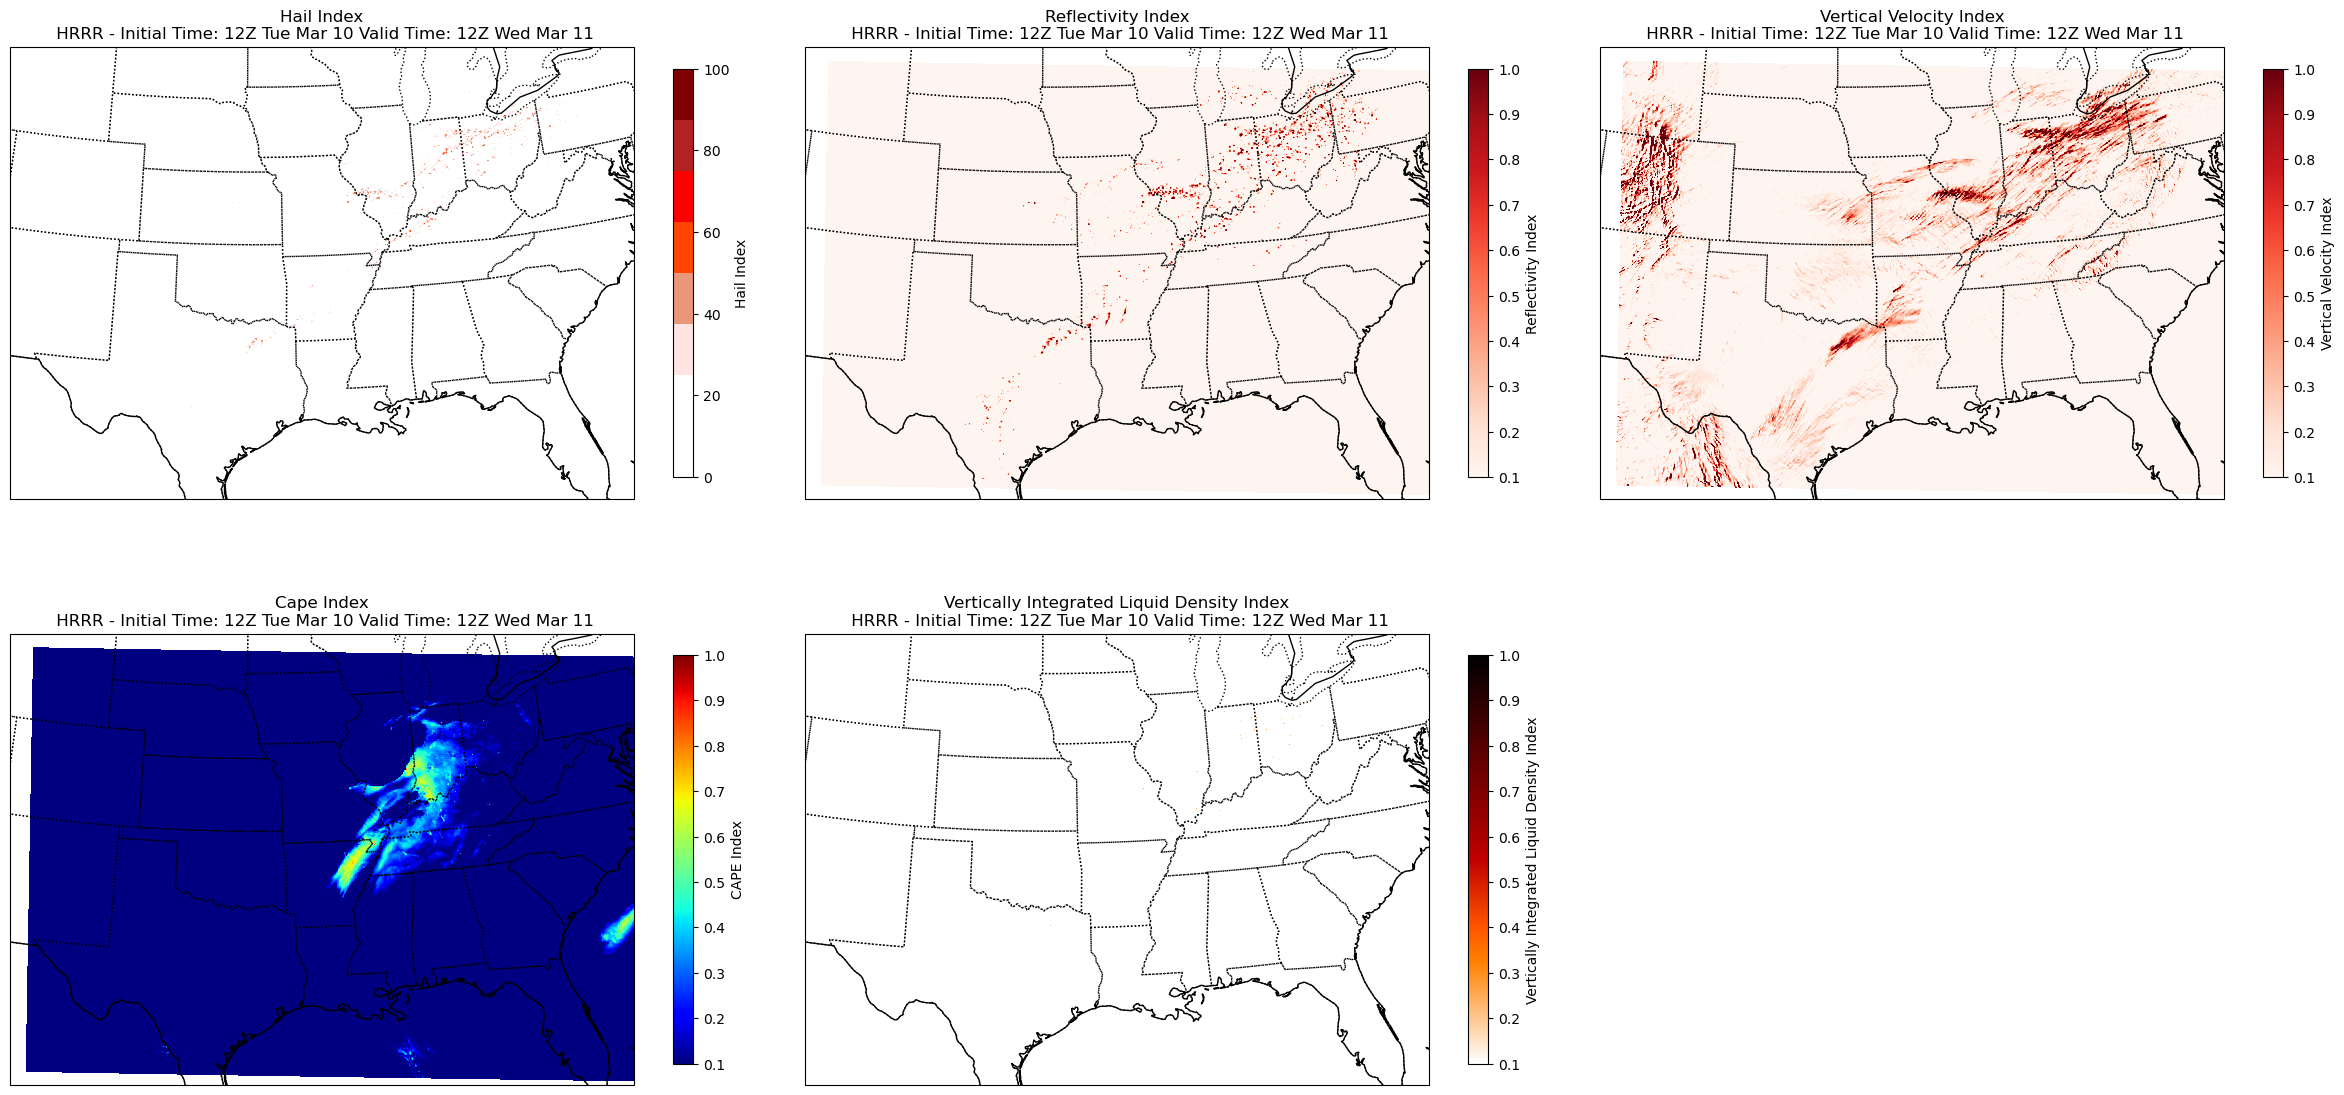

In [32]:
fig, axes = map2(2,3) #calling map2 function
pcolor29 = axes[0,0].pcolormesh(lon, lat, hail_index(ds_file,24), cmap = realcmap, vmax = 100, transform = dataproj) #creating a pcolormesh map for hail index at step 24
plt.colorbar(pcolor29, ax=axes[0,0], label = 'Hail Index', shrink = 0.7) #creating colorbar for the map
axes[0,0].set_title(f"Hail Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=24).values):%HZ %a %b %d}") #title for map at step 24 with model name, valid time and initial time

pcolor30 = axes[1,0].pcolormesh(lon, lat, cape_index(ds_file,24), cmap = 'jet', vmin = 0.1, vmax = 1, transform = dataproj) #creating a pcolormesh map for cape index at step 24
plt.colorbar(pcolor30, ax=axes[1,0], label = 'CAPE Index', shrink = 0.7) #creating colorbar for the map
axes[1,0].set_title(f"Cape Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=24).values):%HZ %a %b %d}") #title for map at step 24 with model name, valid time and initial time

pcolor31 = axes[0,1].pcolormesh(lon, lat, refc_index(ds_file,24), cmap = 'Reds', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for reflectivity index at step 24
plt.colorbar(pcolor31, ax=axes[0,1], label = 'Reflectivity Index', shrink = 0.7) #creating colorbar for the map
axes[0,1].set_title(f"Reflectivity Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=24).values):%HZ %a %b %d}") #title for map at step 24 with model name, valid time and initial time

pcolor32 = axes[1,1].pcolormesh(lon, lat, vil_density_index(ds_file,24), cmap = 'gist_heat_r', vmin = 0.1, vmax = 1, transform = dataproj) #creating a pcolormesh map for vil density index at step 24
plt.colorbar(pcolor32, ax=axes[1,1], label = 'Vertically Integrated Liquid Density Index', shrink = 0.7) #creating colorbar for the map
axes[1,1].set_title(f"Vertically Integrated Liquid Density Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=24).values):%HZ %a %b %d}") #title for map at step 24 with model name, valid time and initial time

pcolor33 =  axes[0,2].pcolormesh(lon, lat, vert_velo_index(ds_file,24), cmap = 'Reds', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for vert velo index at step 24
plt.colorbar(pcolor33, ax=axes[0,2], label = 'Vertical Velocity Index', shrink = 0.7) #creating colorbar for the map
axes[0,2].set_title(f"Vertical Velocity Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=24).values):%HZ %a %b %d}") #title for map at step 24 with model name, valid time and initial time
plt.show()

<GeoAxes: >

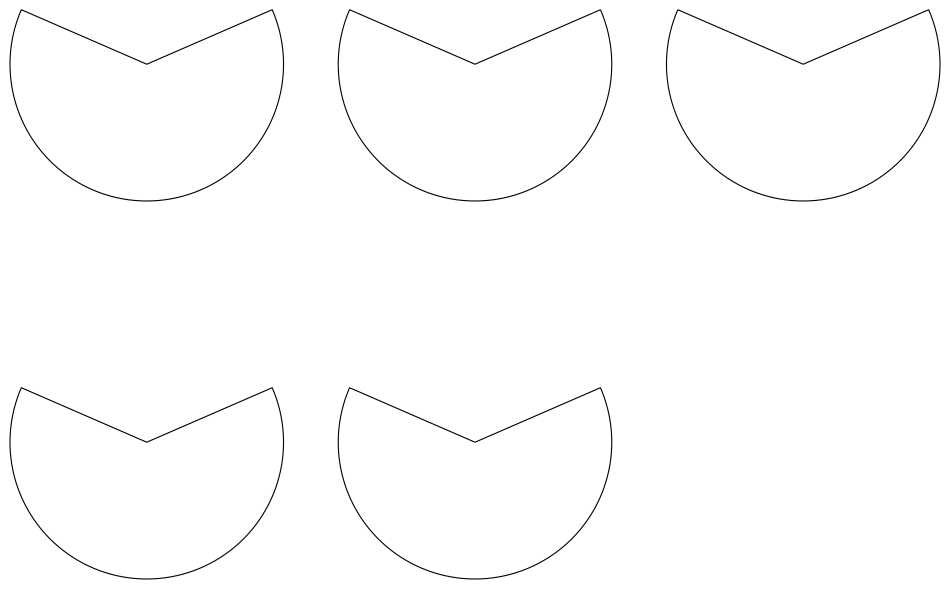

In [31]:
fig,axes = plt.subplots(2,3,figsize=(12,9),subplot_kw = {"projection": ccrs.LambertConformal()})
axes[1,2].set_visible(False)
axes[0,0] #row 0 column 0
axes[1,0] #row 1 column 0
axes[0,1] #row 0 column 1
axes[1,1] #row 1 column 1
axes[0,2] #row 0 column 2



In [33]:
ds_file

<xarray.Dataset> Size: 615MB
Dimensions:                  (valid_time: 49, y: 650, x: 950)
Coordinates:
  * valid_time               (valid_time) datetime64[ns] 392B 2026-03-10T12:0...
    time                     datetime64[ns] 8B ...
    step                     (valid_time) timedelta64[ns] 392B ...
    atmosphere               float64 8B ...
    latitude                 (y, x) float64 5MB 26.62 26.62 ... 42.15 42.14
    longitude                (y, x) float64 5MB 253.6 253.7 ... 286.3 286.4
    cloudTop                 float64 8B ...
    sigmaLayer               float64 8B ...
    pressureFromGroundLayer  float64 8B ...
Dimensions without coordinates: y, x
Data variables:
    refc                     (valid_time, y, x) float32 121MB -10.0 ... -10.0
    cloudtop                 (valid_time, y, x) float32 121MB ...
    veril                    (valid_time, y, x) float32 121MB ...
    wz                       (valid_time, y, x) float32 121MB -0.02435 ... 0.114
    cape                     (valid_time, y, x) float32 121MB 0.0 0.0 ... 0.0
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-03-27T21:28 GRIB to CDM+CF via cfgrib-0.9.1...

# Designing the Threat Index

- Focus for our threat index:

  The focus for our threat index is the optimal spot for dangerous hail formation. This would fall under the specific weather phenomenon category.
  
- Target audience:

  Our target audience is the general public because hail can impact anyone in the area where it falls. 
  
- Scale or range chosen for our index:

  The scale we chose is based on our four variables, with the ones that affect hail the most being weighted the heaviest. When you check this threat index and see that a specific variable is heavily weighted on a given day, it indicates how much that variable influences hail severity. This helps you determine whether to expect severe hail on that day. The severity of hail is rated from 1 to 5, depending on the impact of these variables.

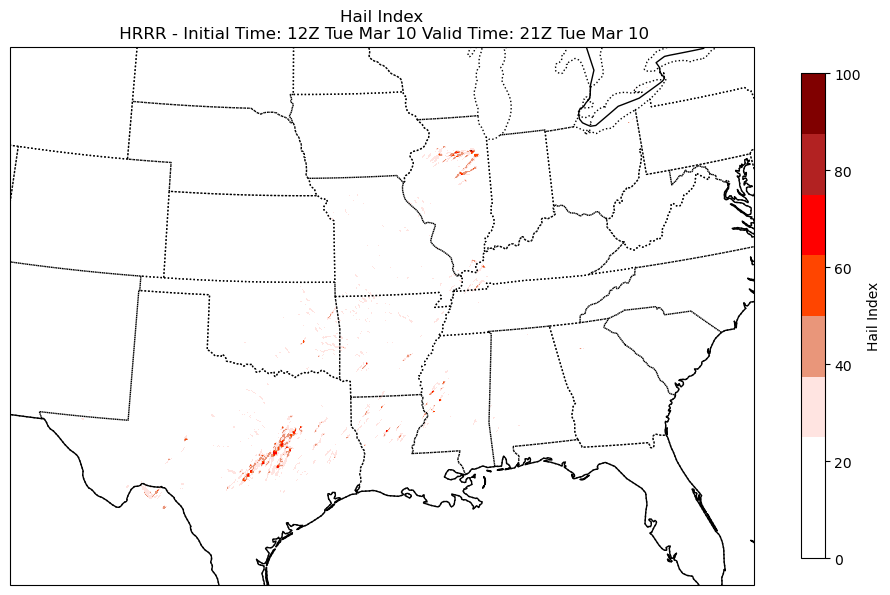

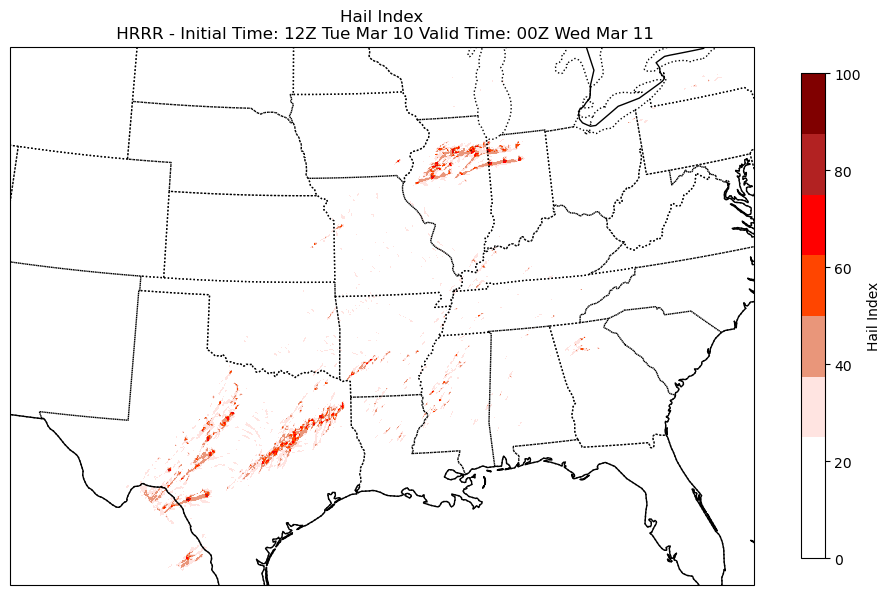

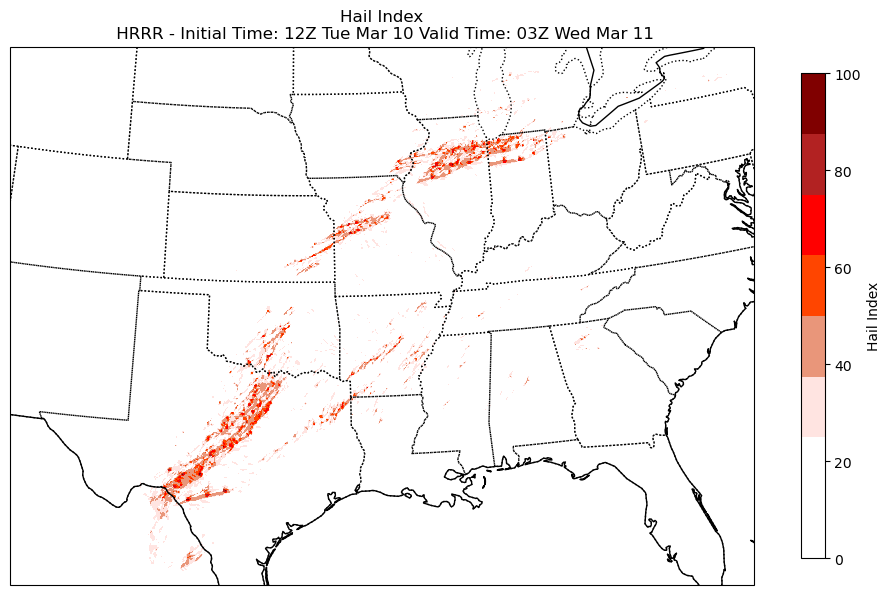

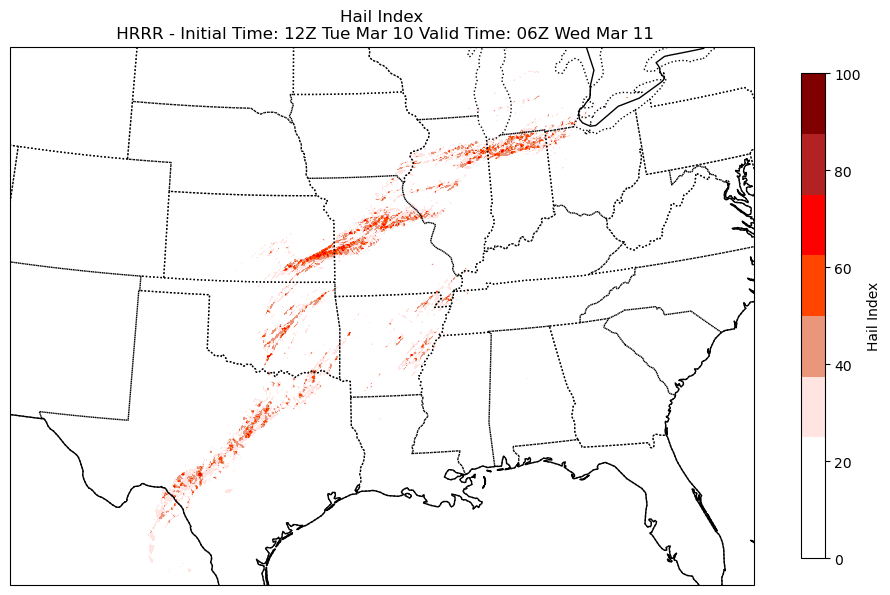

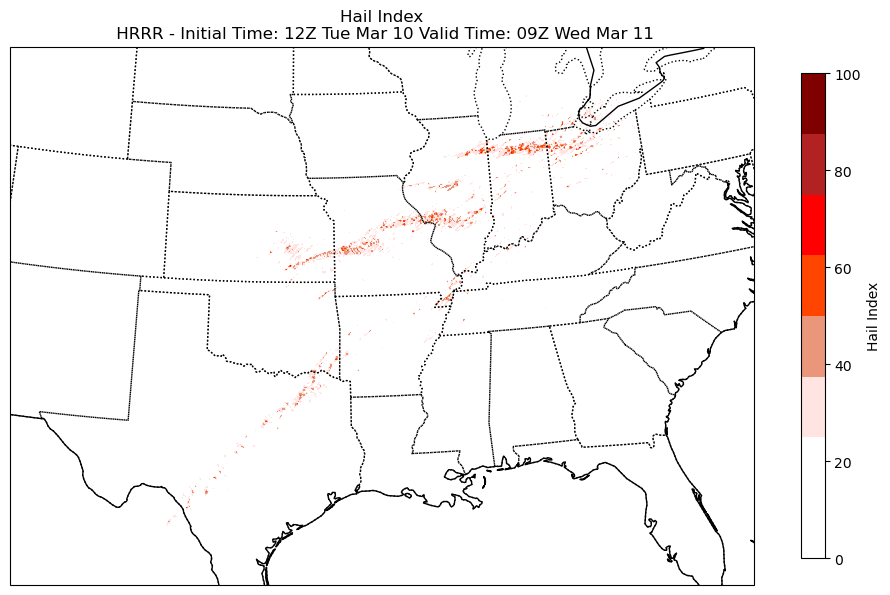

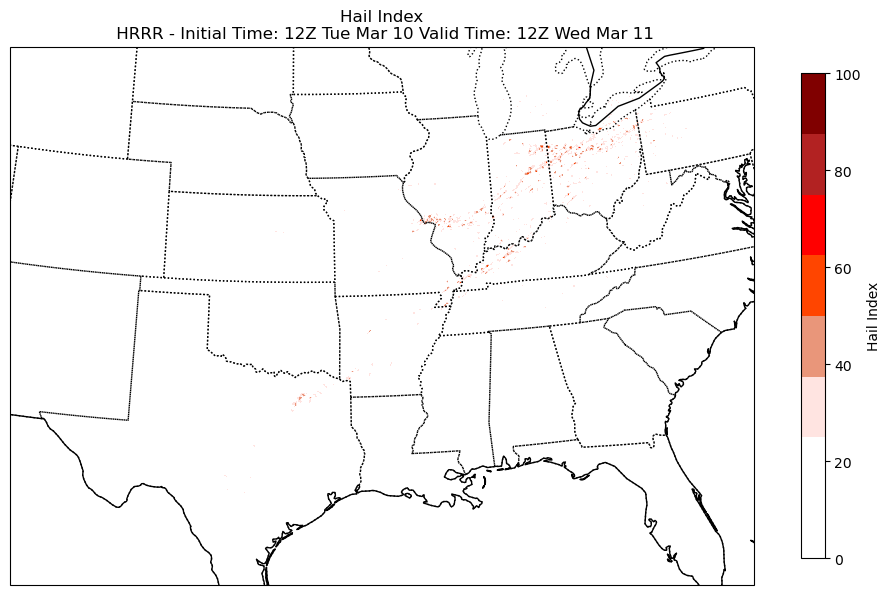

In [43]:
for i in [9,12,15,18,21,24]: #creating for loop over time of the 6 time steps we plotted
    fig, axes = map() #calling map function
    pcolor4 = axes.pcolormesh(lon, lat, hail_index(ds_file,i), cmap = realcmap, vmax = 100, transform = dataproj) #creating a pcolormesh map for hail index at step 9
    plt.colorbar(pcolor4, ax=axes, label = 'Hail Index', shrink = 0.7) #creating colorbar for the map
    axes.set_title(f"Hail Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=i).values):%HZ %a %b %d}") #title for map at step 9 with model name, valid time and initial time
    file_name = "Hail_Index_{0:03d}.png".format(i) #creating hail index file name and formatting it so it can be in terms of time
    #plt.savefig(file_name) #saving hail index figs with the file name format